In [1]:
import pandas as pd

data = pd.read_csv('sales.csv')

df = pd.DataFrame(data)

df.head()



,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [ ]:
df.isnull().sum()  # gives the total null sums in  each column

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [ ]:

for c in ['Quantity','Price Per Unit','Total Spent']:
    df[c] = (
        df[c]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('₹', '', regex=False)
        .str.strip()
    )
    df[c] = pd.to_numeric(df[c], errors='coerce')


In [15]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,9667,9667,9532,9495,9498,7170,6506,9514
unique,9667,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,1951,2349,951,2209,2917,155


In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 9667 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    9667 non-null   str    
 1   Item              9667 non-null   str    
 2   Quantity          9206 non-null   float64
 3   Price Per Unit    9157 non-null   float64
 4   Total Spent       9176 non-null   float64
 5   Payment Method    7170 non-null   str    
 6   Location          6506 non-null   str    
 7   Transaction Date  9514 non-null   str    
dtypes: float64(3), str(5)
memory usage: 679.7 KB


In [24]:
df.duplicated().sum()

np.int64(0)

<Axes: >

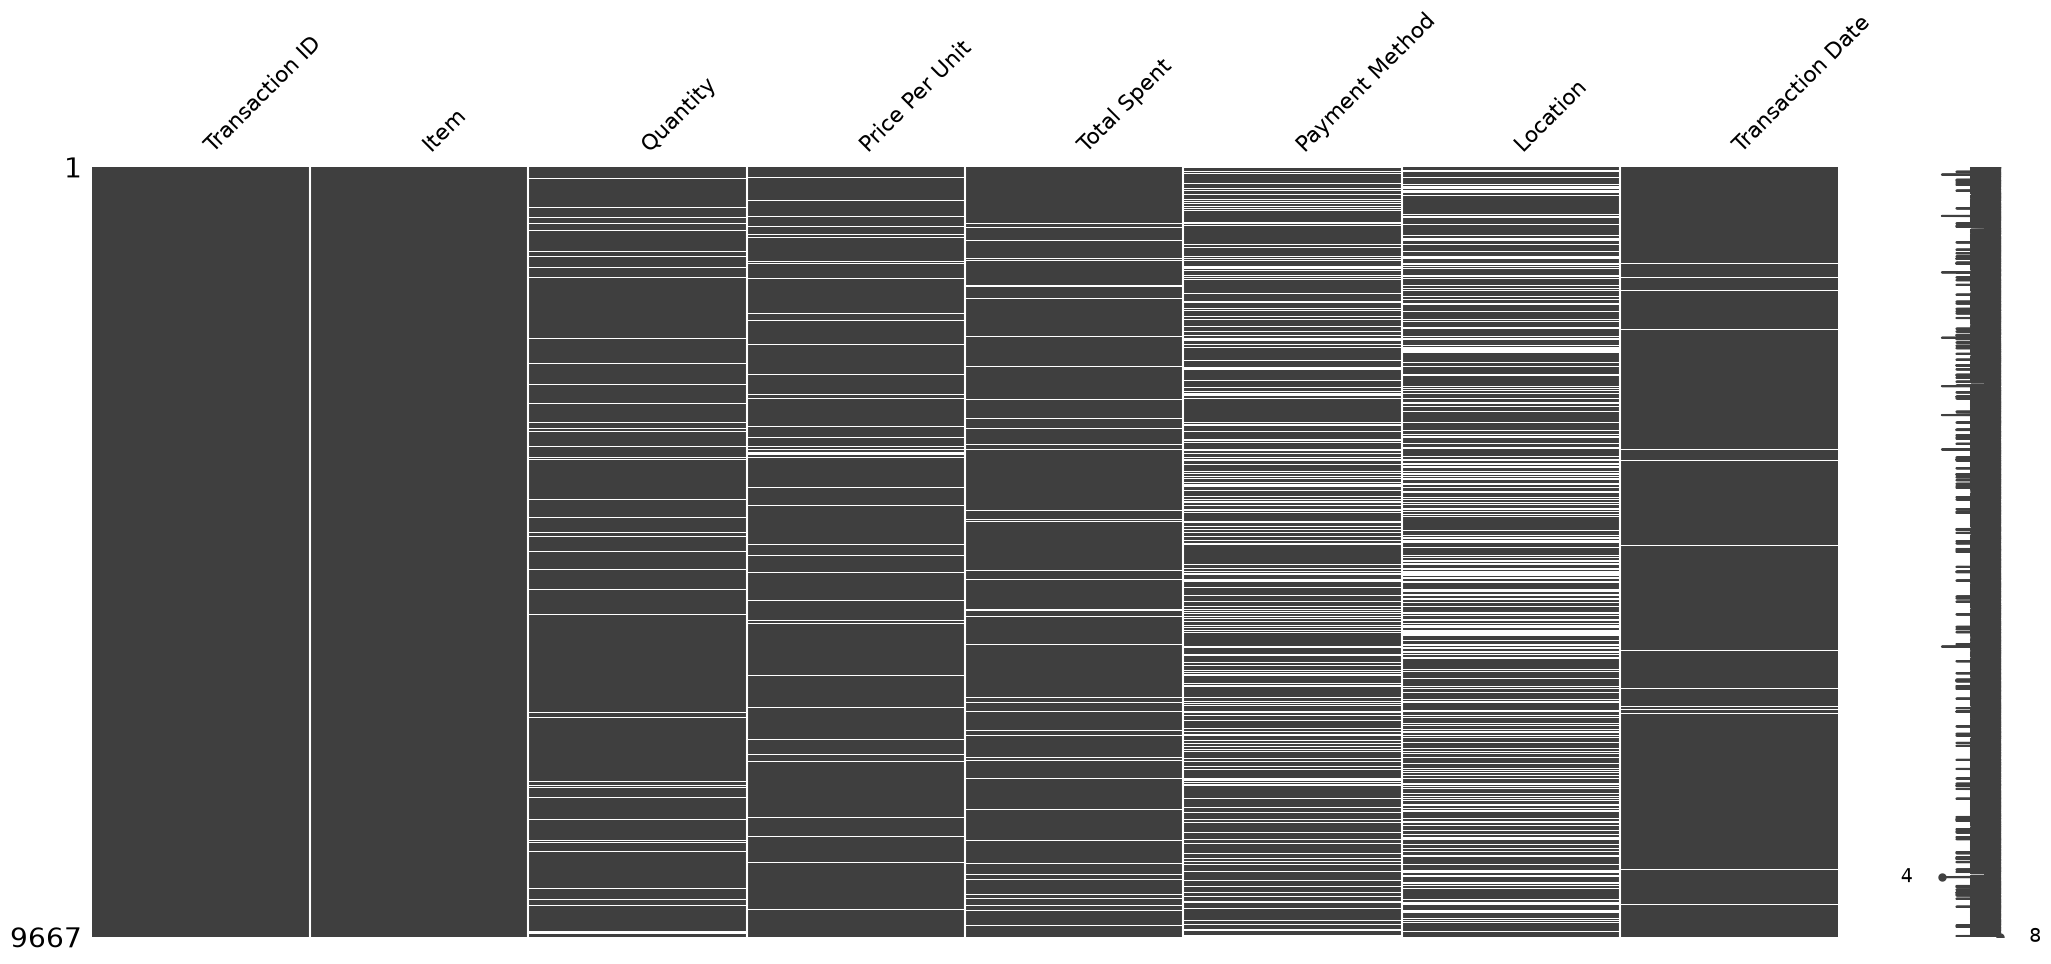

In [ ]:
import missingno as msno

msno.matrix(df)

In [26]:
df_clean = df.copy()
df_clean.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


<Axes: >

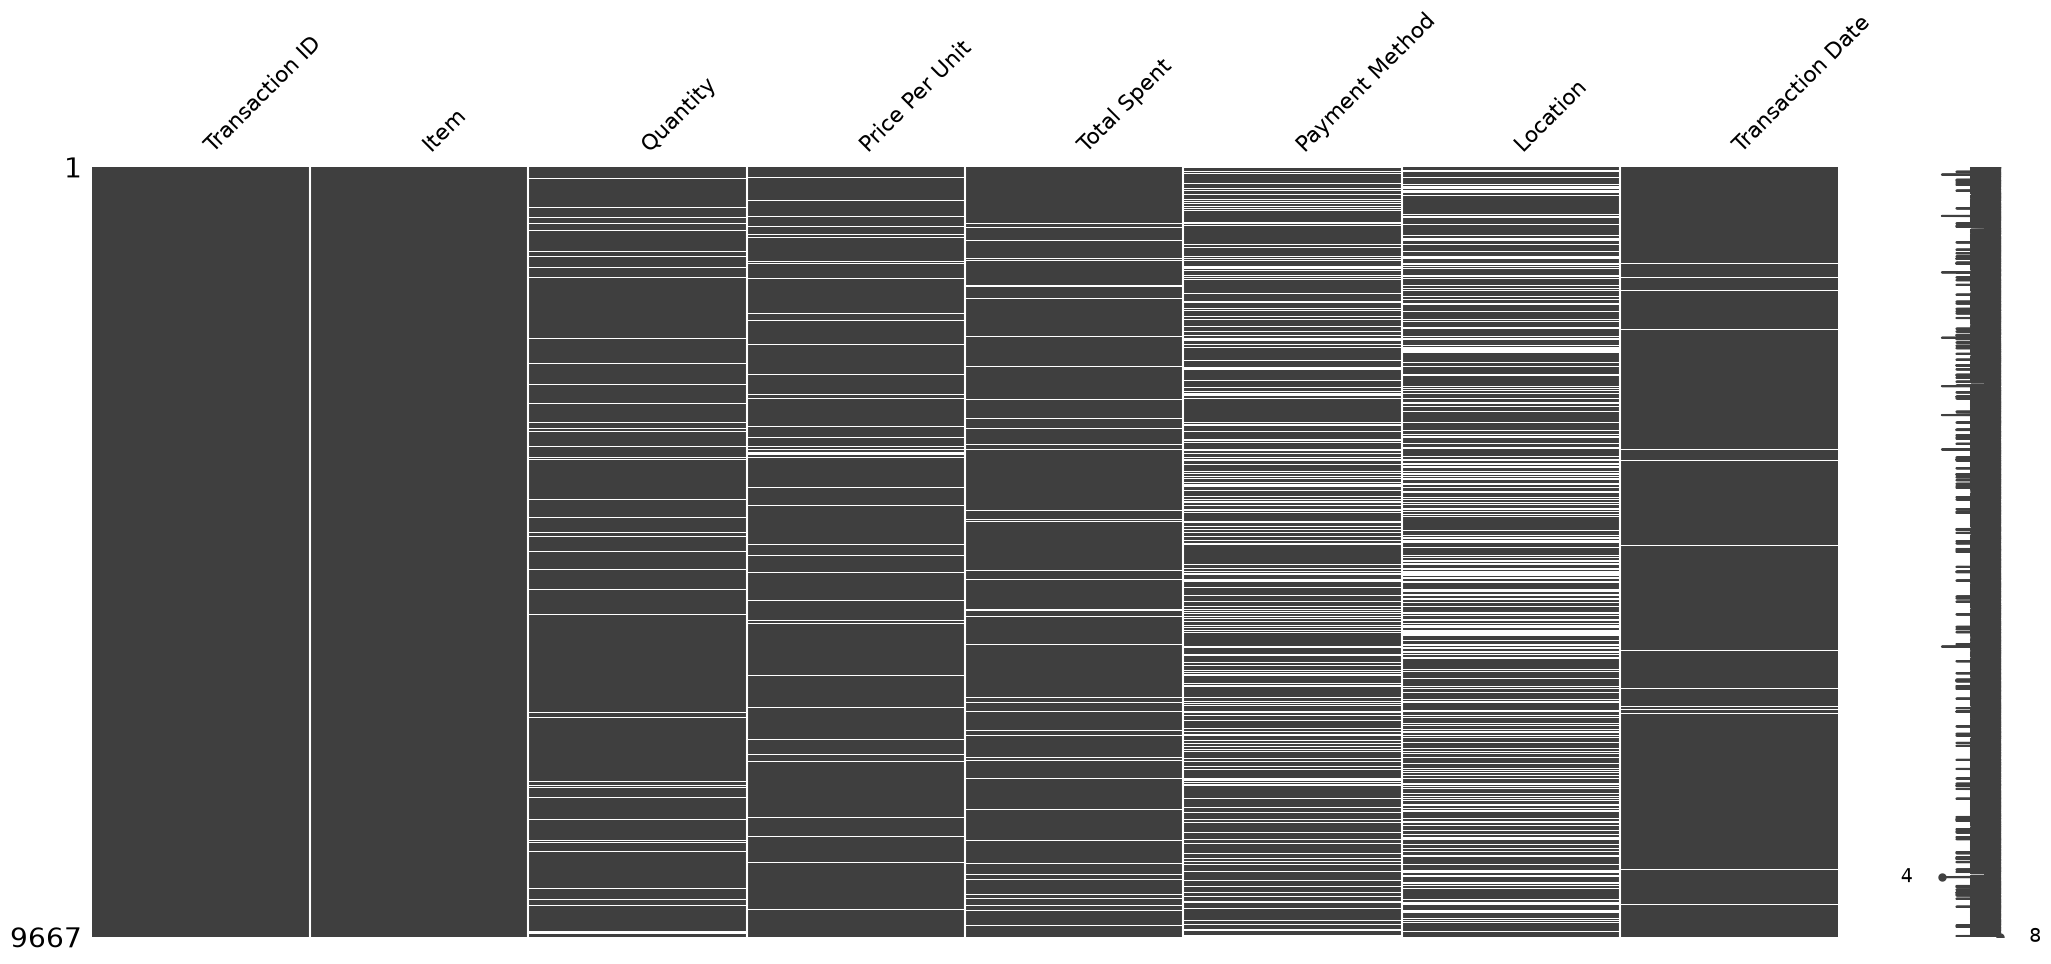

In [ ]:
import missingno as msno

msno.matrix(df)

In [28]:
# first is item column - if item itself is missing then i need to remove the entire row 

df_clean = df_clean.dropna(subset=['Item'])
# or equivalently: df = df[df['item'].notna()]


In [65]:
# mean imputations for quantity 

quantity_imputes = df_clean['Total Spent'] / df['Price Per Unit']
df_clean['Quantity'] = df_clean['Quantity'].fillna(quantity_imputes)


# 
# price_per_unit = Total spent / Quantity
df_clean['Price Per Unit'] = df_clean['Price Per Unit'].fillna(
    df_clean['Total Spent'] / df_clean['Quantity']
)

# total spent imputes 

Total_spent_imputes = df_clean['Quantity'] * df_clean['Price Per Unit']
df_clean['Total Spent'] = df_clean['Total Spent'].fillna(df_clean['Quantity'] * df_clean['Price Per Unit'])


# remove rows where Item is UNKNOWN or ERROR
bad = df_clean['Item'].isin(['UNKNOWN', 'ERROR'])
df_clean = df_clean.loc[~bad].copy()



df_clean['Transaction Date'] = pd.to_datetime(df_clean['Transaction Date'], errors='coerce')
df_clean = df_clean.dropna(subset=['Transaction Date']).copy()


<Axes: >

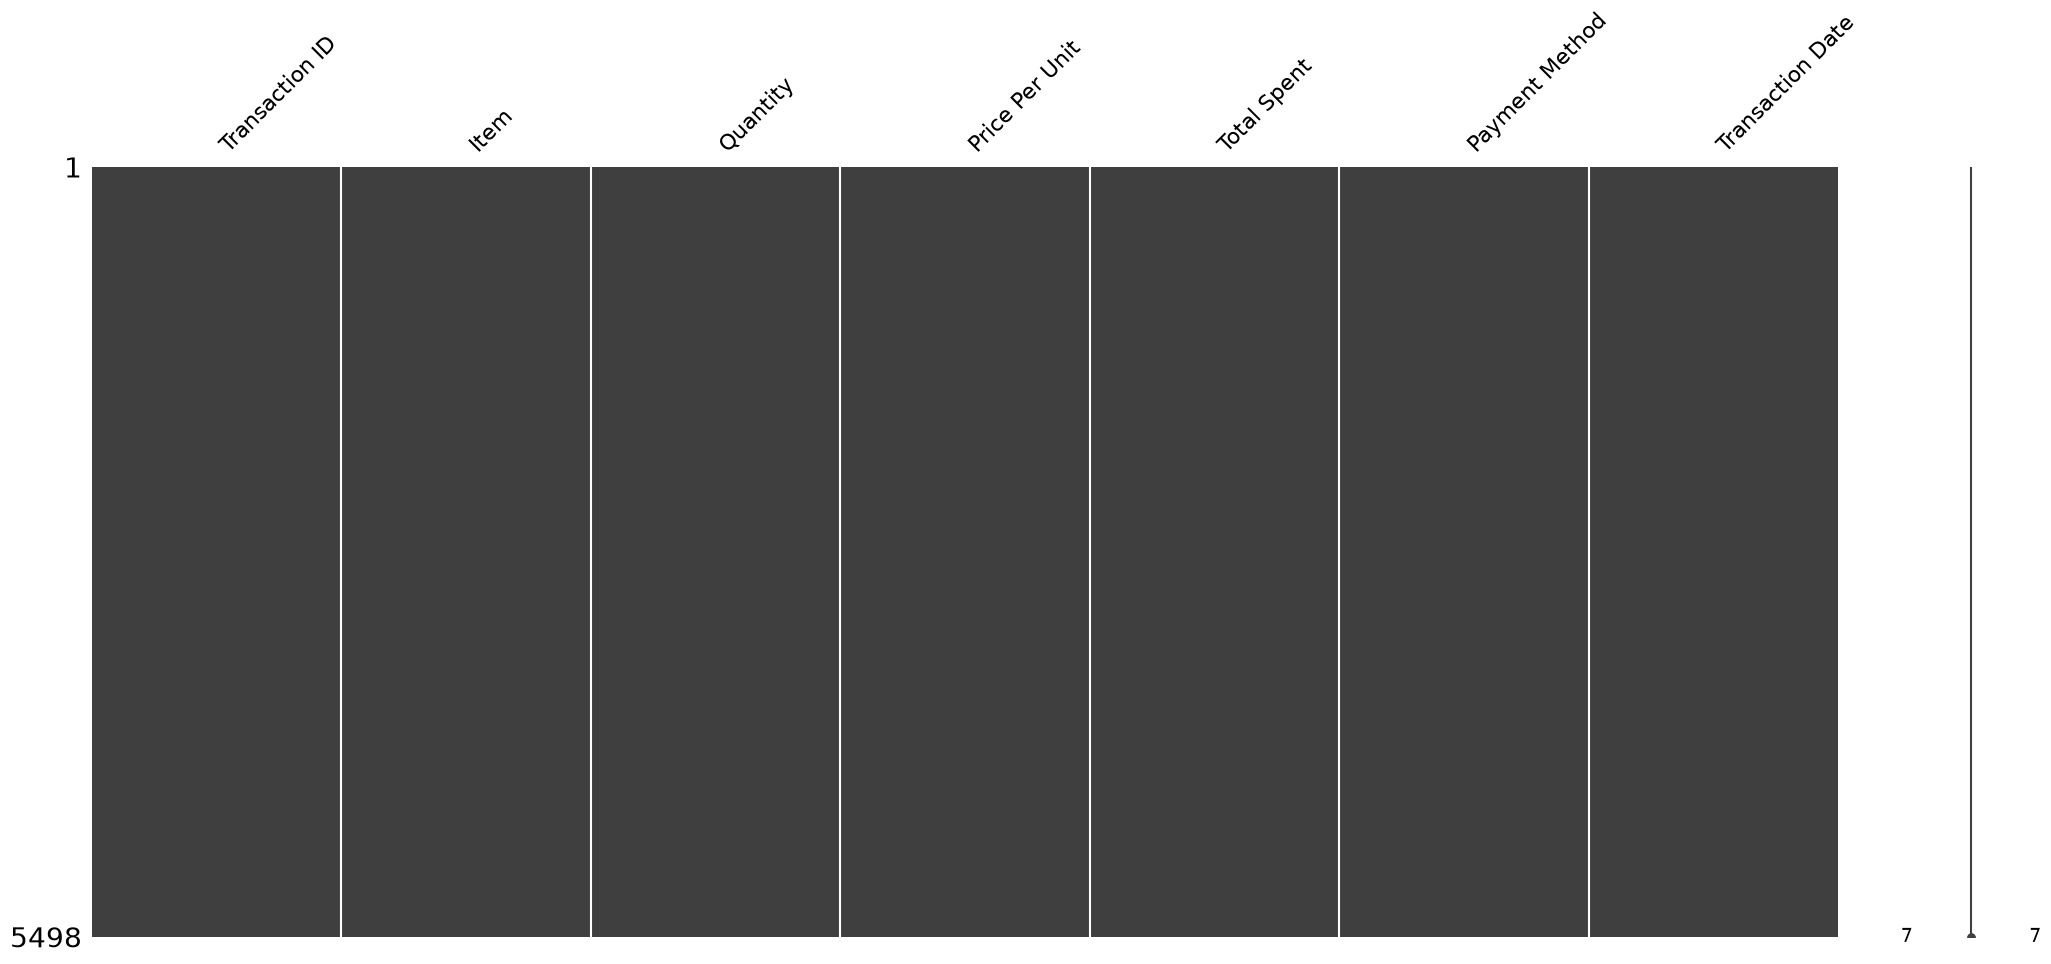

In [66]:
import missingno as msno

msno.matrix(df_clean)

In [36]:
null_pct = (df_clean.isna().mean() * 100).sort_values(ascending=False)
null_pct
# or include counts too:
# pd.DataFrame({'null_count': df.isna().sum(), 'null_pct': df.isna().mean()*100})


Location            32.698872
Payment Method      25.830144
Transaction Date     1.582704
Total Spent          0.403434
Quantity             0.382745
Price Per Unit       0.372401
Transaction ID       0.000000
Item                 0.000000
dtype: float64

In [70]:
df_clean = df_clean.drop(columns=['Location', 'Payment Method'], errors='ignore')
# high nulls droppend 

In [71]:
# drop rows where ANY column has null
df_clean = df_clean.dropna()


<Axes: >

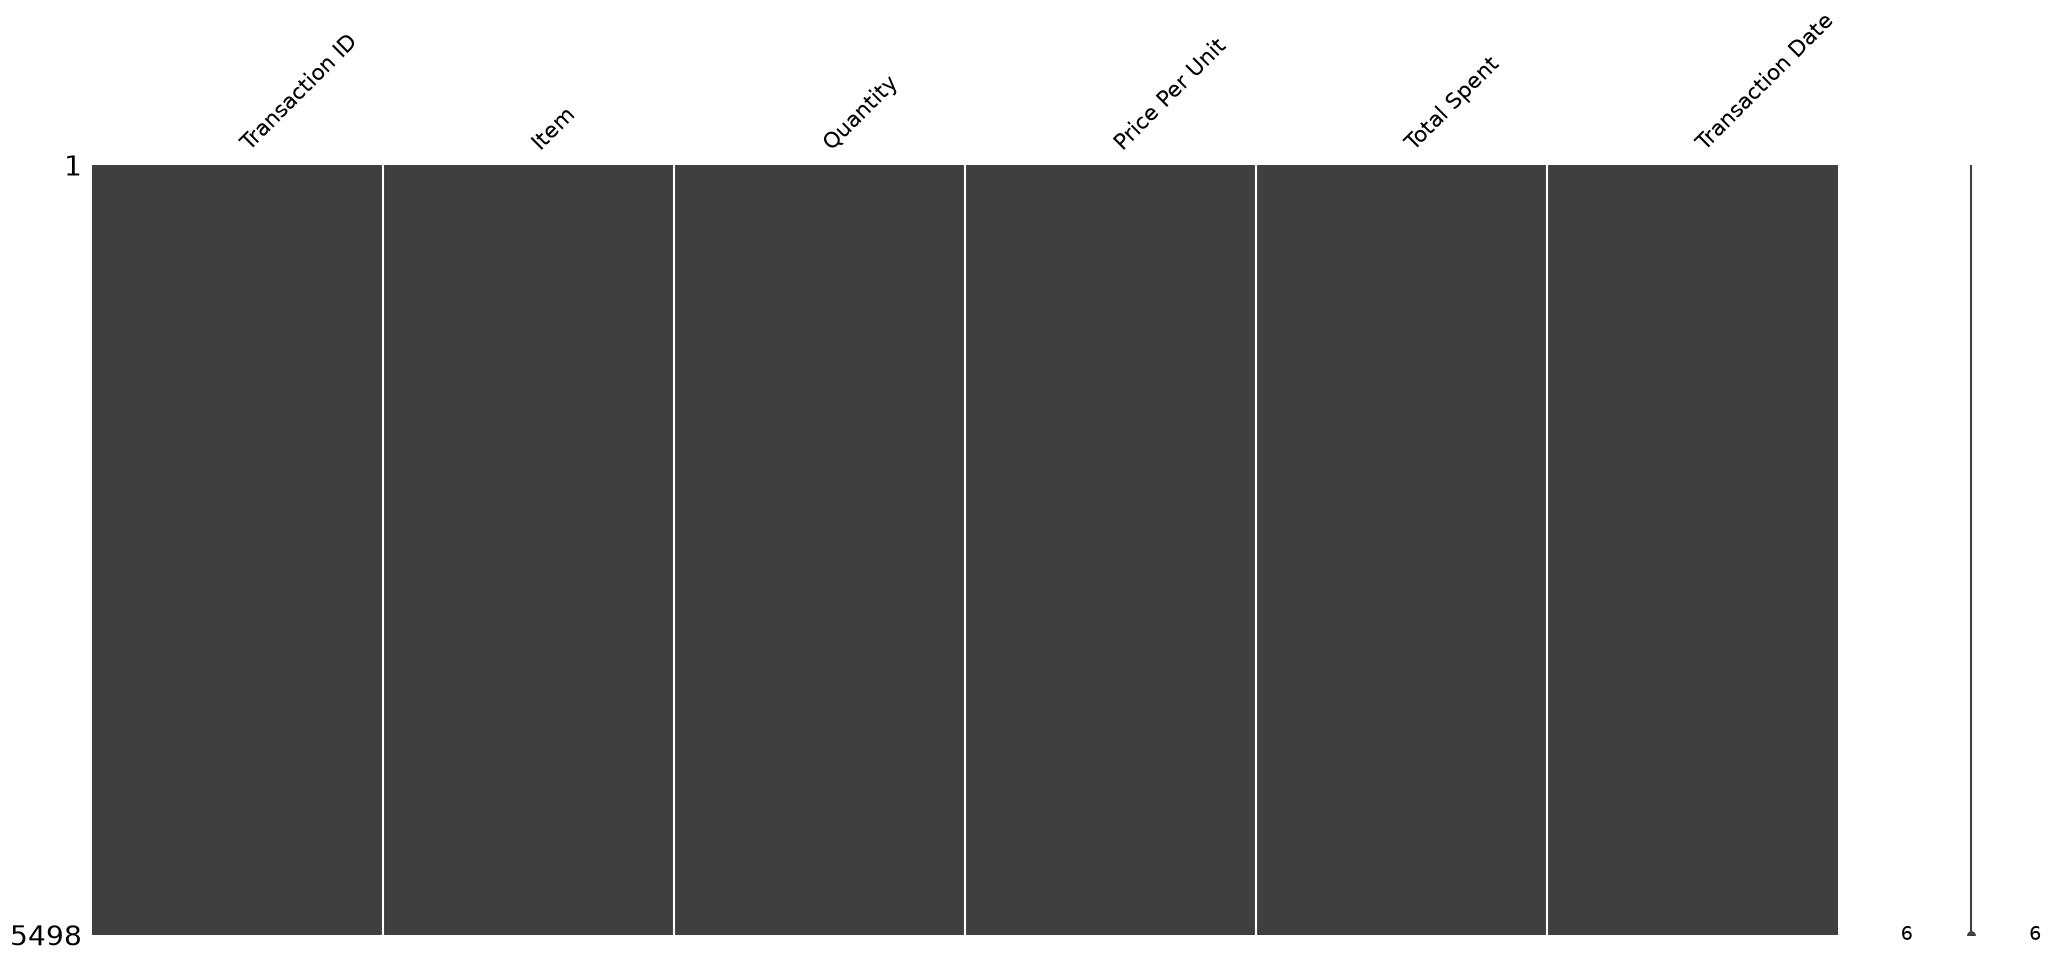

In [72]:
msno.matrix(df_clean)

In [73]:
# cleaned dataset , now export to csv 
df_clean.to_csv("cleaned_sales.csv", index=False)


# Univariate

count    5498.000000
mean        8.965624
std         5.992802
min         1.000000
25%         4.000000
50%         8.000000
75%        12.000000
max        25.000000
Name: Total Spent, dtype: float64


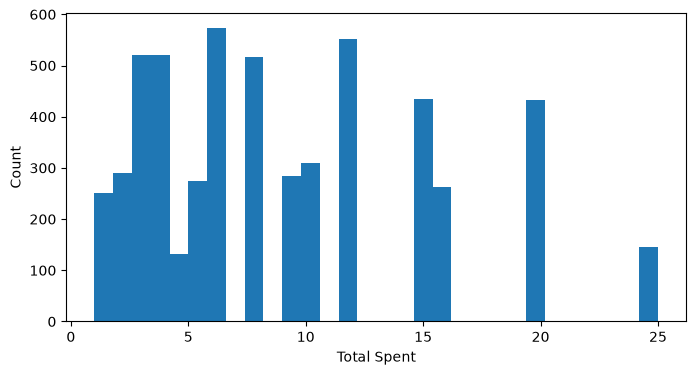

In [74]:
import matplotlib.pyplot as plt

# univariate distribution (histogram)
plt.figure(figsize=(8,4))
plt.hist(df_clean['Total Spent'].dropna(), bins=30)
plt.xlabel('Total Spent')
plt.ylabel('Count')


# quick summary
print(df_clean['Total Spent'].describe())


# bivariate 

In [88]:
r = df[['Price Per Unit','Total Spent']].corr()
print(r)


                Price Per Unit  Total Spent
Price Per Unit        1.000000     0.645389
Total Spent           0.645389     1.000000


<BarContainer object of 5498 artists>

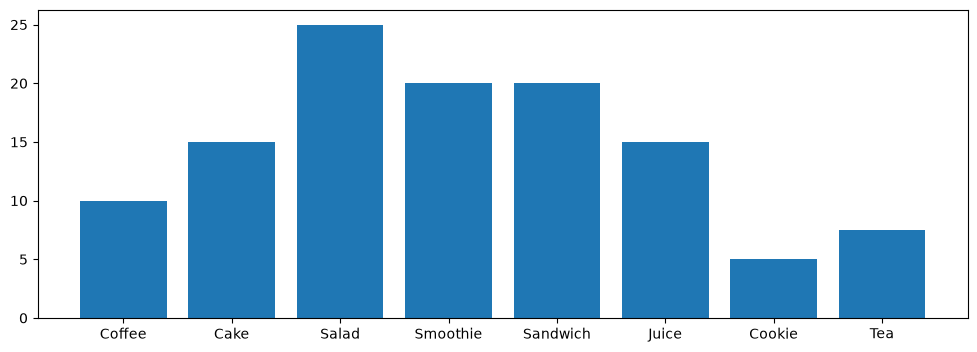

In [75]:
import matplotlib.pyplot as plt
plt.figure(figsize= (12,4))
plt.bar(df_clean['Item'], df_clean['Total Spent'])


salad is the highes sales item  , smoothy and sandwich are second highes sales 
least sales was on cookie 

In [83]:

r = df_clean[['Price Per Unit','Total Spent']].corr()
print(r)


                Price Per Unit  Total Spent
Price Per Unit        1.000000     0.644984
Total Spent           0.644984     1.000000


In [56]:
df_clean.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,2023-06-11


In [85]:
df_clean.info()


<class 'pandas.DataFrame'>
Index: 5498 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    5498 non-null   str           
 1   Item              5498 non-null   str           
 2   Quantity          5498 non-null   float64       
 3   Price Per Unit    5498 non-null   float64       
 4   Total Spent       5498 non-null   float64       
 5   Transaction Date  5498 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 300.7 KB


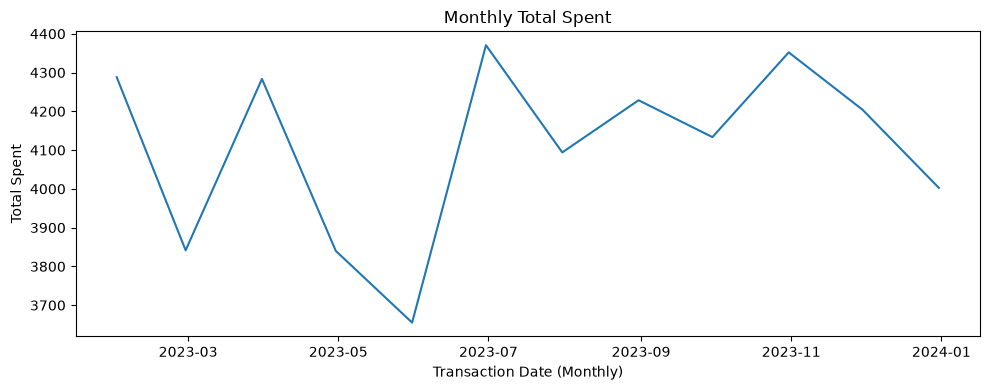

In [86]:
# monthly line chart: Transaction Date vs Total Spent
import pandas as pd
import matplotlib.pyplot as plt

# ensure datetime
df_clean['Transaction Date'] = pd.to_datetime(df_clean['Transaction Date'], errors='coerce')

monthly = (df_clean
    .dropna(subset=['Transaction Date', 'Total Spent'])
    .set_index('Transaction Date')
    .resample('ME')['Total Spent']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,4))
plt.plot(monthly['Transaction Date'], monthly['Total Spent'])
plt.xlabel('Transaction Date (Monthly)')
plt.ylabel('Total Spent')
plt.title('Monthly Total Spent')
plt.tight_layout()
plt.show()


yearly - sales trends as per the transaction dates 